Complete the exercises below For **Assignment #5**.

In this exercise, we are building a logistic regression classification model. We'll work with the [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database).  

Load the `tidymodels` library. 

In [2]:
library(tidymodels)

── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.13     ✔ recipes      1.4.0 
✔ dials        1.4.4      ✔ rsample      1.3.2 
✔ dplyr        1.2.1      ✔ tailor       0.1.0 
✔ ggplot2      4.0.3      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.6.0      ✔ workflows    1.3.0 
✔ parsnip      1.6.1      ✔ workflowsets 1.1.1 
✔ purrr        1.2.2      ✔ yardstick    1.4.0 

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()



The data is located in your homework directory in the `diabetes.csv` file. Read in the data by running the following cell. We are "splitting" the data into training and testing sets. We will evaluate our model's performance with the test set.

In [3]:
diabetes = readr::read_csv('diabetes.csv') |> mutate(Outcome = factor(Outcome))

split = initial_split(diabetes, strata = Outcome)

diabetes_train = training(split)
diabetes_test = testing(split)

Rows: 768 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (9): Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, D...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Glimpse the `diabetes_train` table.

In [4]:

glimpse(diabetes_train)


Rows: 576
Columns: 9
$ Pregnancies              <dbl> 1, 5, 10, 1, 3, 1, 13, 5, 3, 6, 10, 4, 3, 7, …
$ Glucose                  <dbl> 85, 116, 115, 103, 126, 97, 145, 117, 88, 92,…
$ BloodPressure            <dbl> 66, 74, 0, 30, 88, 66, 82, 92, 58, 92, 78, 60…
$ SkinThickness            <dbl> 29, 0, 0, 38, 41, 15, 19, 0, 11, 0, 31, 33, 2…
$ Insulin                  <dbl> 0, 0, 0, 83, 235, 140, 110, 0, 54, 0, 0, 192,…
$ BMI                      <dbl> 26.6, 25.6, 35.3, 43.3, 39.3, 23.2, 22.2, 34.…
$ DiabetesPedigreeFunction <dbl> 0.351, 0.201, 0.134, 0.183, 0.704, 0.487, 0.2…
$ Age                      <dbl> 31, 30, 29, 33, 27, 22, 57, 38, 22, 28, 45, 3…
$ Outcome                  <fct> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


❓ Which variable is suitable as the "outcome" in a logistic regression model?

**Answer:**

The Outcome variable is suitable because it is a binary categorical variable with two possible values, 0 and 1.

❓ Navigate to [Kaggle page](https://www.kaggle.com/datasets/mathchi/diabetes-data-set) for this dataset. Find descriptions for the `Glucose` and `BMI` columns. Add these descriptions to the [Markdown table](https://www.markdownguide.org/extended-syntax/#tables) below.

| Column | Description |
|---|---|
| **Glucose** | Plasma glucose concentration 2 hours after an oral glucose tolerance test |
| **BMI** | Body mass index (weight in kg divided by height in meters squared) |

| Column name | Description |
| :---------- | :---------- |
| Glucose     |             |
| BMI         |             |

Make a bar chart showing the frequency of each "outcome" in the `Outcome` column from your `diabetes_train` data.

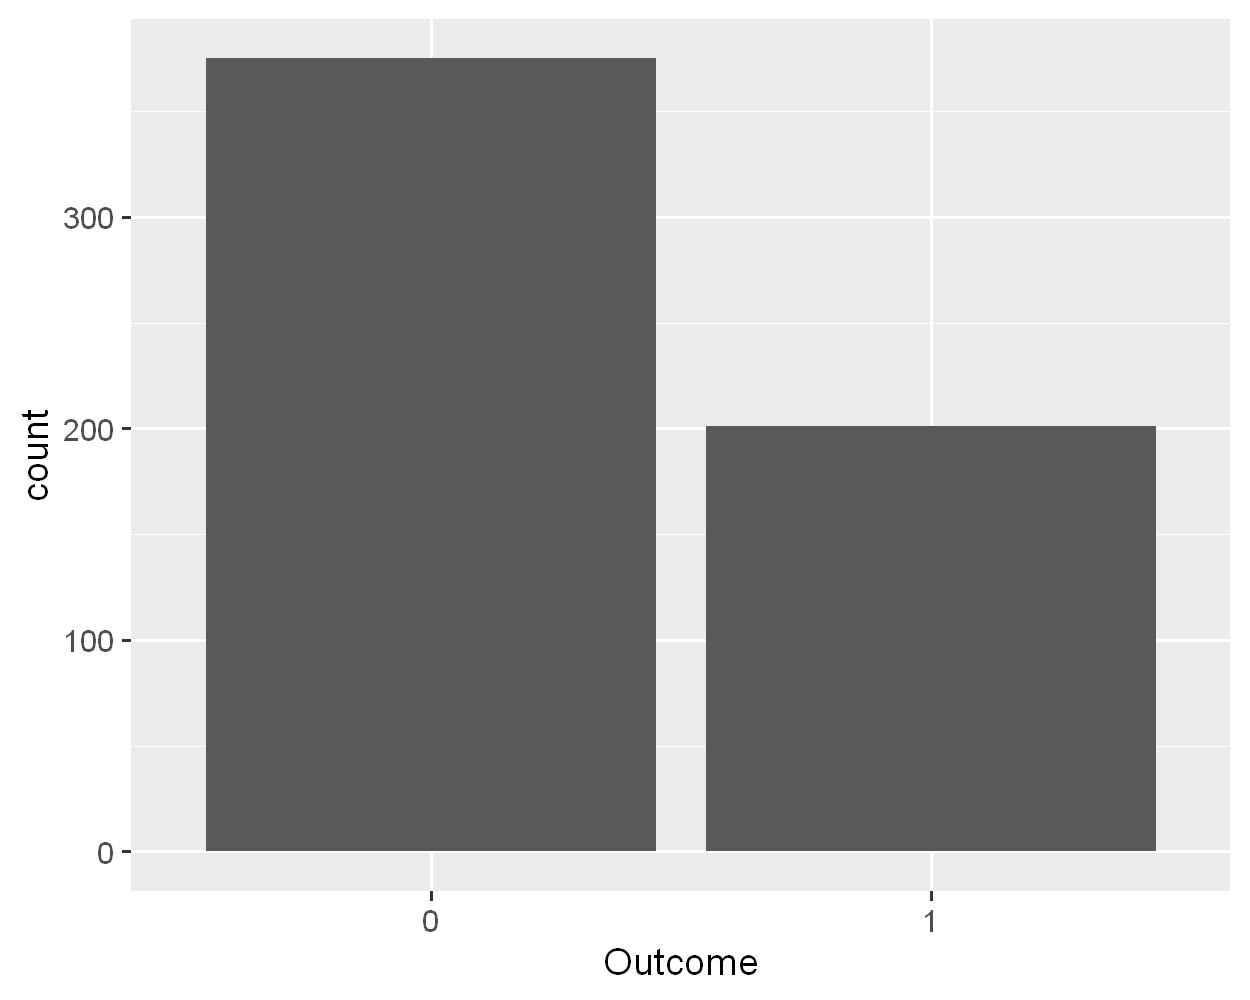

In [5]:
ggplot(diabetes_train, aes(x = Outcome)) +
  geom_bar()

❓ Is the data balanced? I.e. do we have equal counts of each outcome?

**Answer:**


No, the data is not balanced. There are more observations with Outcome = 0 than Outcome = 1, so the two outcomes do not have equal counts.


Run the code below to create a table for plotting the predictors we will use in our model: `Glucose` and `BMI`. 

In [6]:
plot_df = diabetes_train |>
    select(Outcome, Glucose, BMI) |>
    pivot_longer(cols = c(Glucose, BMI))

plot_df |> head()

Outcome,name,value
<fct>,<chr>,<dbl>
0,Glucose,85.0
0,BMI,26.6
0,Glucose,116.0
0,BMI,25.6
0,Glucose,115.0
0,BMI,35.3


Using `plot_df`, make a chart showing the relationship of `Glucose` and `BMI` with `Outcome`. 

- use `geom_jitter` for your "geom"
- `facet_wrap` your chart by the `name` variable. (e.g. `facet_wrap(~name, ncol = 2, scales = 'free_x')`)

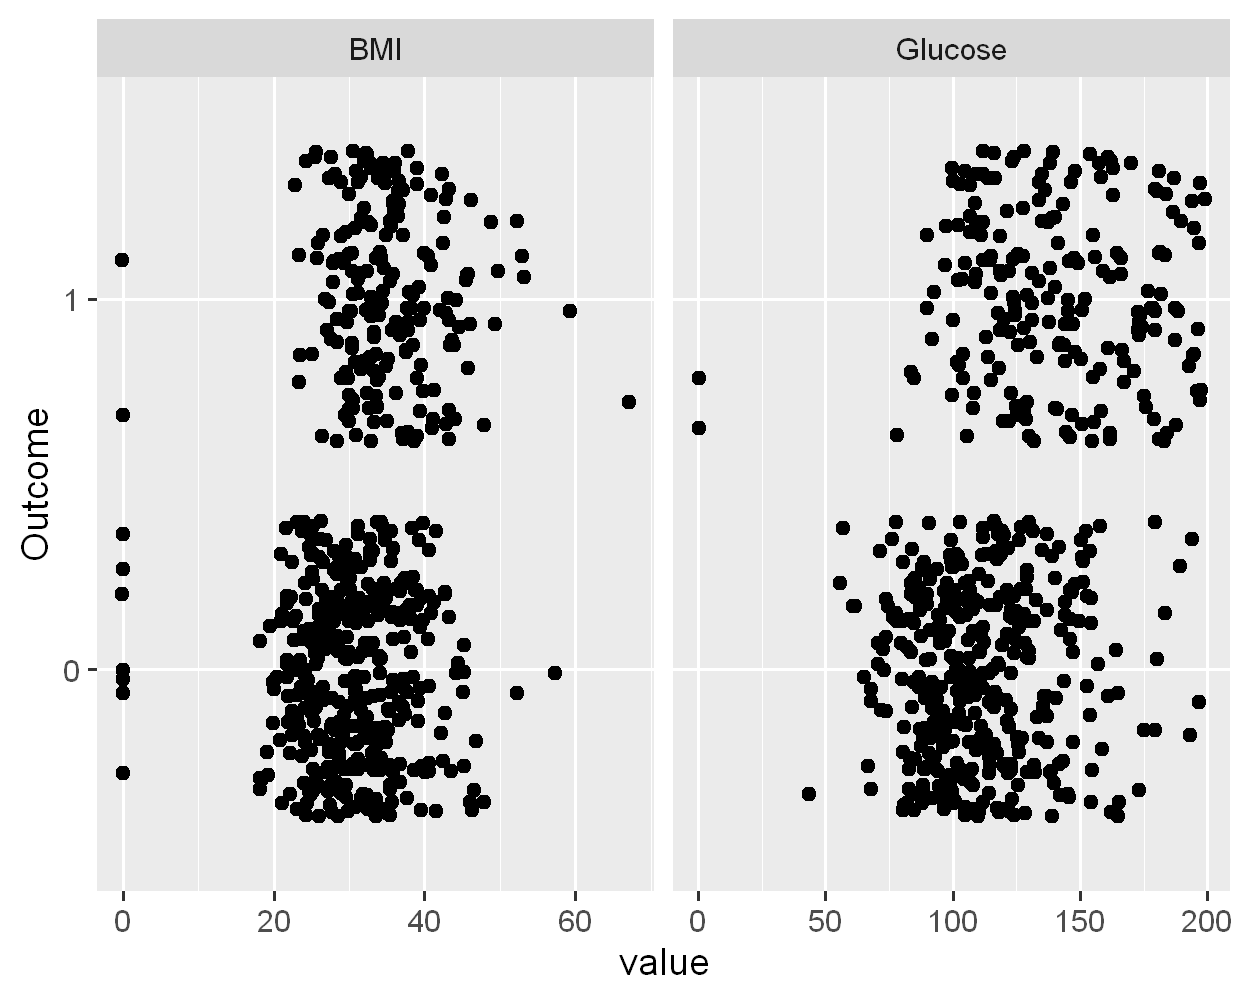

In [7]:

ggplot(plot_df, aes(x = value, y = Outcome)) +
  geom_jitter() +
  facet_wrap(~name, ncol = 2, scales = "free_x")


❓ What happens when you remove the `scales = 'free_x'` argument from the `facet_wrap` function?

**Answer:**

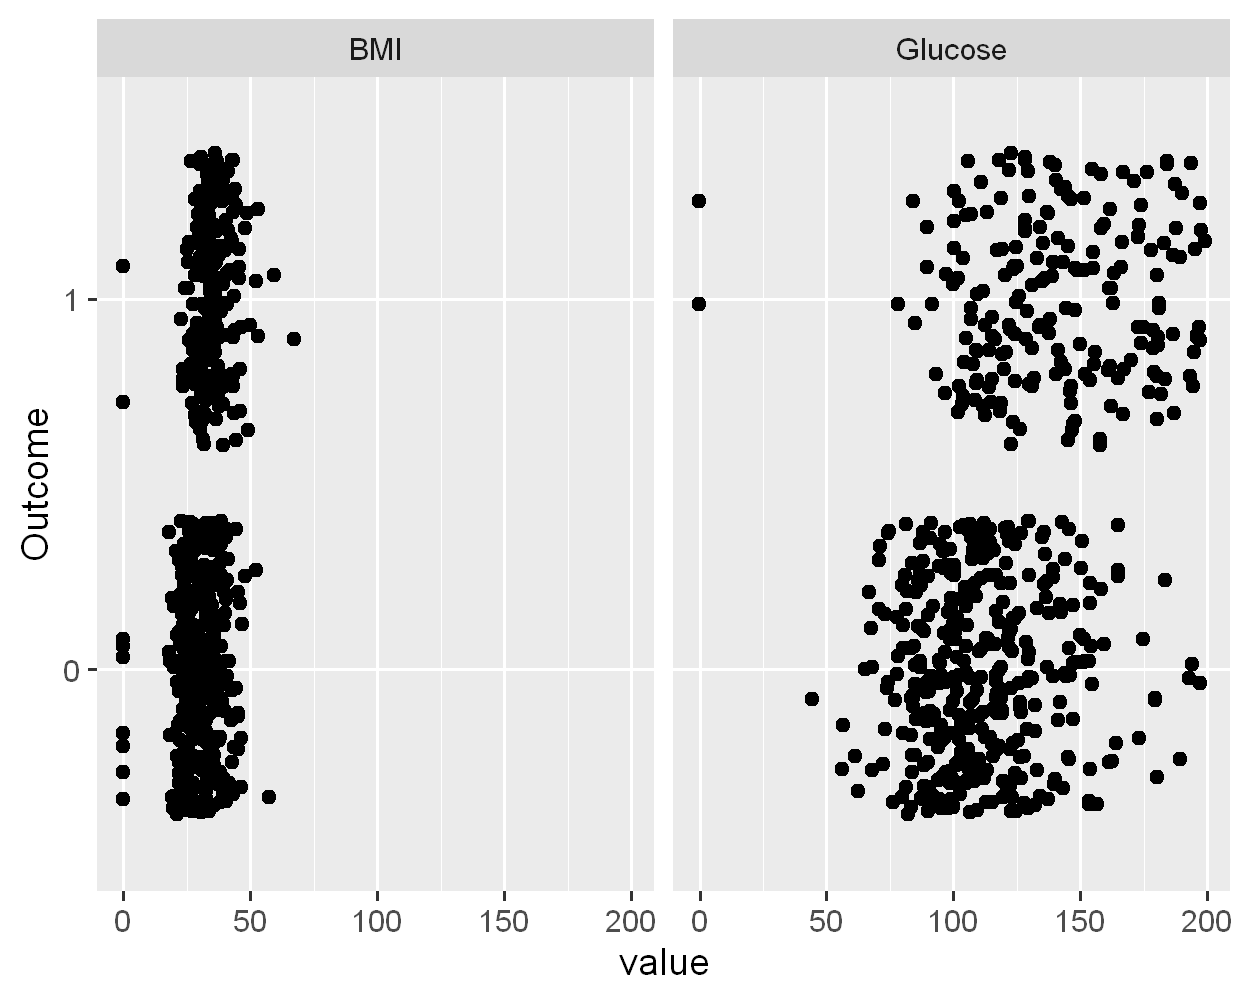

In [8]:
ggplot(plot_df, aes(x = value, y = Outcome)) +
  geom_jitter() +
  facet_wrap(~name, ncol = 2)

When scales = "free_x" is removed, both plots use the same x-axis scale. This causes the BMI values to look more compressed because BMI has a much smaller range than Glucose.

Using your training data, build logistic regression model of `Outcome` with `BMI` and `Glucose` as predictors. 
- Use "glm" for you engine
- The formula for your fit function will be `Outcome ~ BMI + Glucose`

In [9]:


diabetes_fit <- logistic_reg() |>
  set_engine("glm") |>
  fit(Outcome ~ BMI + Glucose, data = diabetes_train)

diabetes_fit

parsnip model object


Call:  stats::glm(formula = Outcome ~ BMI + Glucose, family = stats::binomial, 
    data = data)

Coefficients:
(Intercept)          BMI      Glucose  
   -6.84640      0.07012      0.03143  

Degrees of Freedom: 575 Total (i.e. Null);  573 Residual
Null Deviance:	    745.1 
Residual Deviance: 599.8 	AIC: 605.8

Using `augment` with your fitted model and the `diabetes_test` data as arguments, create a new dataset called `diabetes_test_wPred` that is the `diabetes_test` table including predictions from your model. 

In [10]:

diabetes_test_wPred <- augment(diabetes_fit, diabetes_test)

diabetes_test_wPred |> head()


.pred_class,.pred_0,.pred_1,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
0,0.8888073,0.1111927,1,89,66,23,94,28.1,0.167,21,0
0,0.6797037,0.3202963,4,110,92,0,0,37.6,0.191,30,0
1,0.2499903,0.7500097,10,168,74,0,0,38.0,0.537,34,1
0,0.6404142,0.3595858,10,139,80,0,0,27.1,1.441,57,0
0,0.6911742,0.3088258,1,115,70,30,96,34.6,0.529,32,1
0,0.7777188,0.2222812,8,99,84,0,0,35.4,0.388,50,0


Run the code below to generate a confusion matrix for your model predictions. 

(❗️Hint: See Table 4.4 from [*Introduction to Statistical Learning (Version 2)*](https://www.statlearning.com/) for an example confusion matrix.)

In [12]:
diabetes_test_wPred = augment(diabetes_fit, new_data = diabetes_test)

diabetes_test_wPred |> conf_mat(Outcome, .pred_class)

          Truth
Prediction   0   1
         0 118  34
         1   7  33

❓ Based on the confusion matrix above, 
- How many individuals had diabetes in your test data?
- Of those that actually had diabetes, how many were predicted to have diabetes by your model?
- How many individuals predicted to have diabetes did not have diabetes?

**Answer:**

| Question | Answer |
|---|---:|
| Individuals who actually had diabetes | 67 |
| Individuals with diabetes correctly predicted to have diabetes | 33 |
| Individuals predicted to have diabetes but did not have diabetes | 7 |

The test data contained 67 individuals with diabetes. The model correctly predicted 33 of them as having diabetes, while 7 individuals were predicted to have diabetes but actually did not.